In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
(X_train , y_train)  ,(X_test , y_test) = mnist.load_data()

In [3]:
X_train = X_train/255
X_test = X_test/255

In [4]:
X_train.max()

1.0

In [5]:
X_train = X_train.reshape((-1,784))
X_test = X_test.reshape((-1,784))

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential

In [7]:
# encoder
encoder = Sequential(name = 'encoder')
encoder.add(Dense(units=128 , activation='relu' , input_shape = (784,)))
encoder.add(Dense(units=64 , activation='relu'))
encoder.add(Dense(units=32 , activation='relu'))

# decoder
decoder = Sequential(name='decoder')
decoder.add(Dense(units=64 , activation='relu' , input_shape = (32,)))
decoder.add(Dense(units=128 , activation='relu'))
decoder.add(Dense(units=784 , activation='sigmoid'))

# auto encoder
auto_encoder = Sequential(name='auto_encoder')
auto_encoder.add(encoder)
auto_encoder.add(decoder)

d:\python-venv\keras2\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
auto_encoder.summary()

Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.MeanSquaredError()

auto_encoder.compile(optimizer= opt , loss= loss)

In [12]:
auto_encoder.fit(X_train , X_train  , validation_data= (X_test , X_test) , epochs=120 , batch_size=50 , verbose=2)

Epoch 1/120
1200/1200 - 14s - 12ms/step - loss: 0.0349 - val_loss: 0.0203
Epoch 2/120
1200/1200 - 11s - 9ms/step - loss: 0.0177 - val_loss: 0.0151
Epoch 3/120
1200/1200 - 11s - 10ms/step - loss: 0.0143 - val_loss: 0.0129
Epoch 4/120
1200/1200 - 11s - 9ms/step - loss: 0.0126 - val_loss: 0.0117
Epoch 5/120
1200/1200 - 20s - 17ms/step - loss: 0.0116 - val_loss: 0.0109
Epoch 6/120
1200/1200 - 14s - 11ms/step - loss: 0.0108 - val_loss: 0.0103
Epoch 7/120
1200/1200 - 19s - 16ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 8/120
1200/1200 - 20s - 17ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 9/120
1200/1200 - 21s - 17ms/step - loss: 0.0093 - val_loss: 0.0089
Epoch 10/120
1200/1200 - 7s - 5ms/step - loss: 0.0090 - val_loss: 0.0087
Epoch 11/120
1200/1200 - 2s - 2ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 12/120
1200/1200 - 2s - 2ms/step - loss: 0.0086 - val_loss: 0.0083
Epoch 13/120
1200/1200 - 2s - 2ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 14/120
1200/1200 - 3s - 2ms/step - los

In [16]:
X_pred = auto_encoder(X_train)

In [17]:
import matplotlib.pyplot as plt
import numpy as np

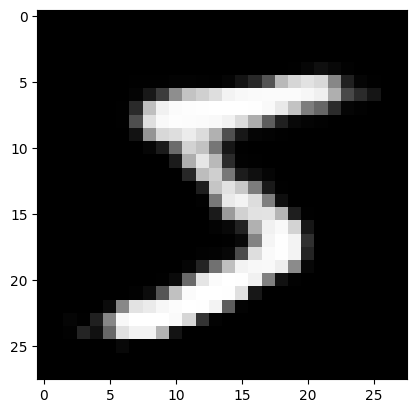

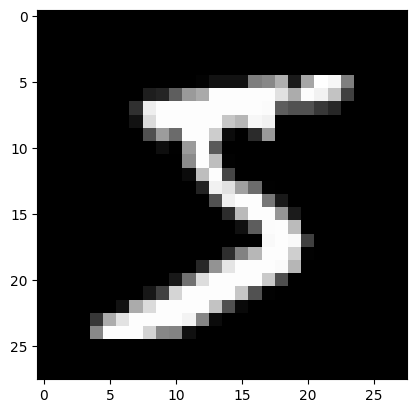

In [18]:
plt.imshow(np.reshape(X_pred[0],(28,28)) , cmap='gray')
plt.show()
plt.imshow(np.reshape(X_train[0],(28,28)) , cmap='gray')
plt.show()